   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 MB 17.5 MB/s eta 0:00:00
170.4 MiB [] 0% 0.0s170.4 MiB [] 0% 42.1s170.4 MiB [] 0% 15.6s170.4 MiB [] 0% 15.0s170.4 MiB [] 0% 10.4s170.4 MiB [] 1% 5.3s170.4 MiB [] 2% 4.0s170.4 MiB [] 3% 3.4s170.4 MiB [] 3% 3.2s170.4 MiB [] 4% 3.4s170.4 MiB [] 5% 3.0s170.4 MiB [] 6% 2.6s170.4 MiB [] 7% 2.4s170.4 MiB [] 8% 2.3s170.4 MiB [] 9% 2.3s170.4 MiB [] 10% 2.2s170.4 MiB [] 11% 2.1s170.4 MiB [] 12% 2.0s170.4 MiB [] 13% 1.9s170.4 MiB [] 14% 1.8s170.4 MiB [] 14% 1.9s170.4 MiB [] 15% 1.8s170.4 MiB [] 16% 1.8s170.4 MiB [] 17% 1.7s170.4 MiB [] 18% 1.7s170.4 MiB [] 19% 1.7s170.4 MiB [] 20% 1.7s170.4 MiB [] 21% 1.6s170.4 MiB [] 23% 1.6s170.4 MiB [] 24% 1.5s170.4 MiB [] 25% 1.4s170.4 MiB [] 27% 1.4s170.4 MiB [] 28% 1.4s170.4 MiB [] 29% 1.3s170.4 MiB [] 30% 1.3s170.4 MiB [] 31% 1.2s170.4 MiB [] 33% 1.2s170.4 MiB [] 34% 1.2s170.4 MiB [] 35% 1.1s170.4 MiB [] 37% 1.1s170.4 MiB [] 38% 1.1s170.4 MiB [] 39% 1.0s170.4 MiB [] 40% 1.0s170.4 MiB [] 42% 1.0s170.4 Mi

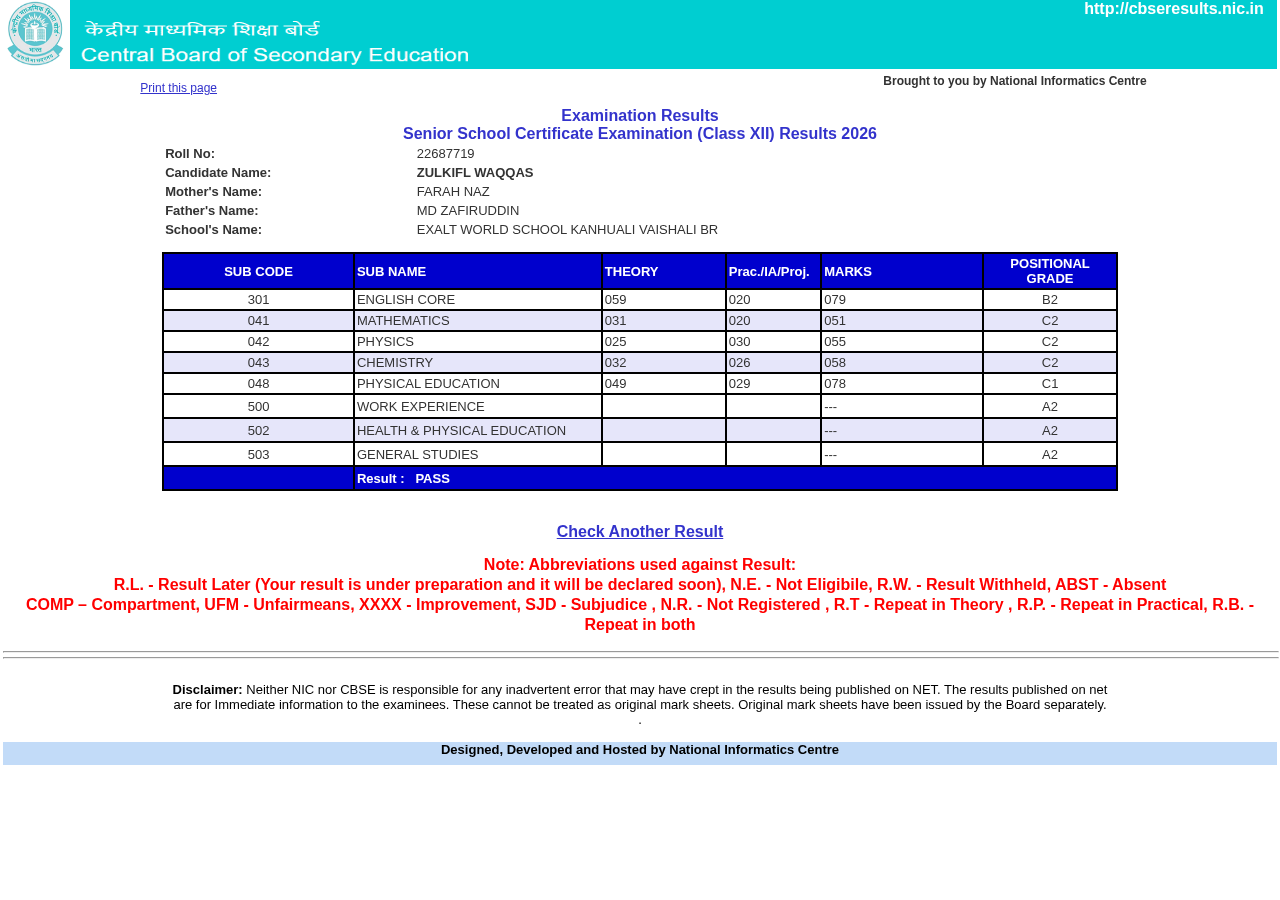


── Roll No: 22687772 ──────────────────────────


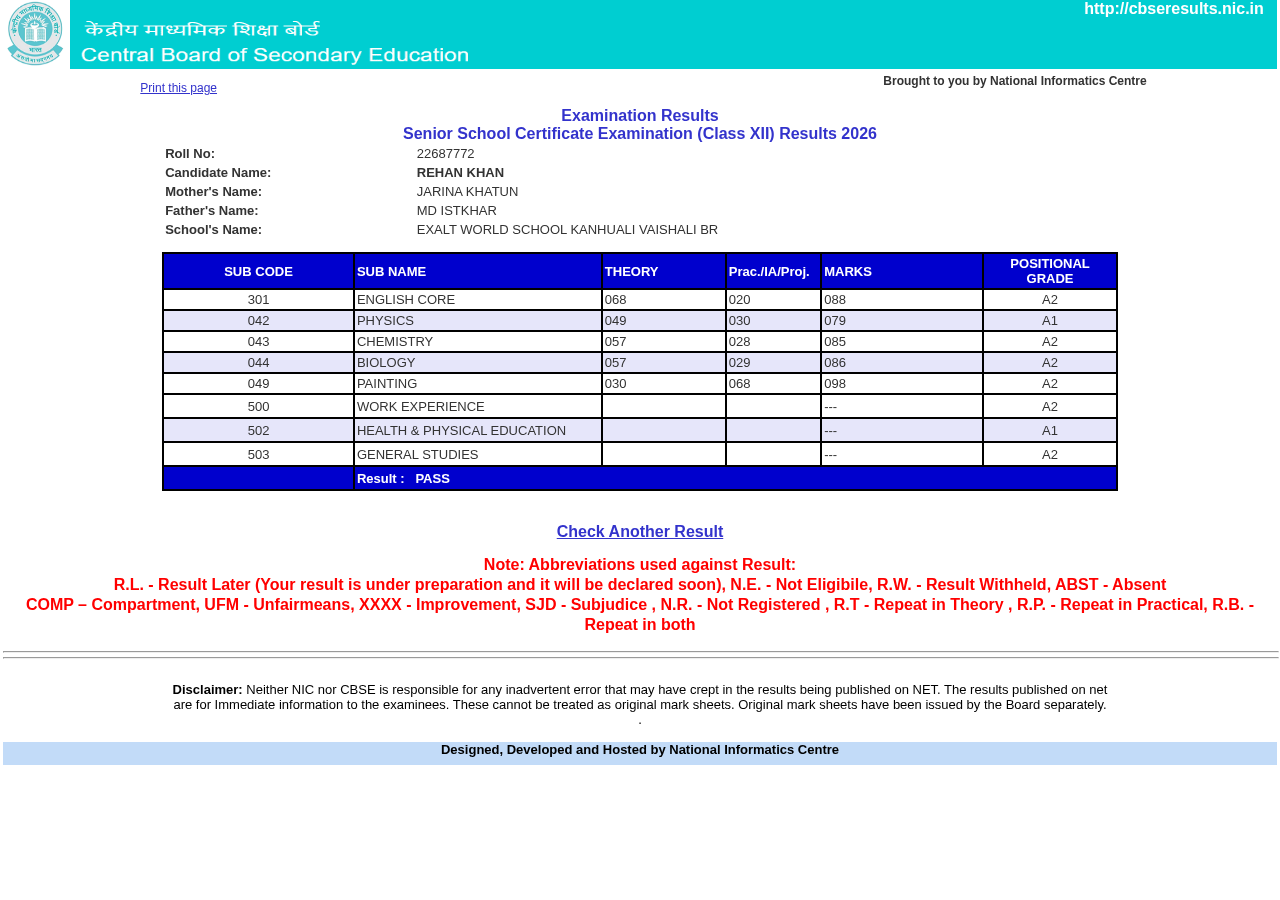


── Roll No: 22687735 ──────────────────────────


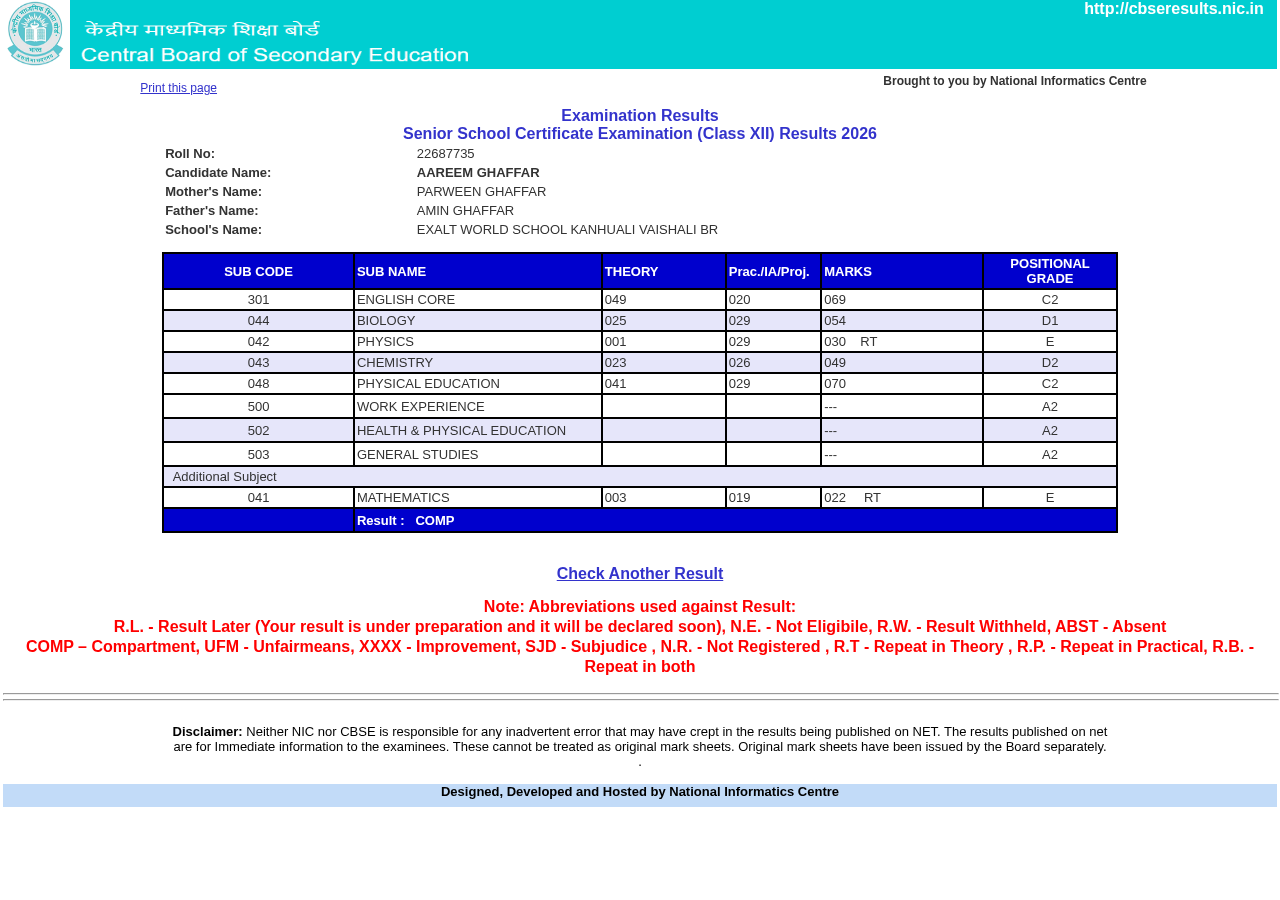


── Roll No: 22687747 ──────────────────────────


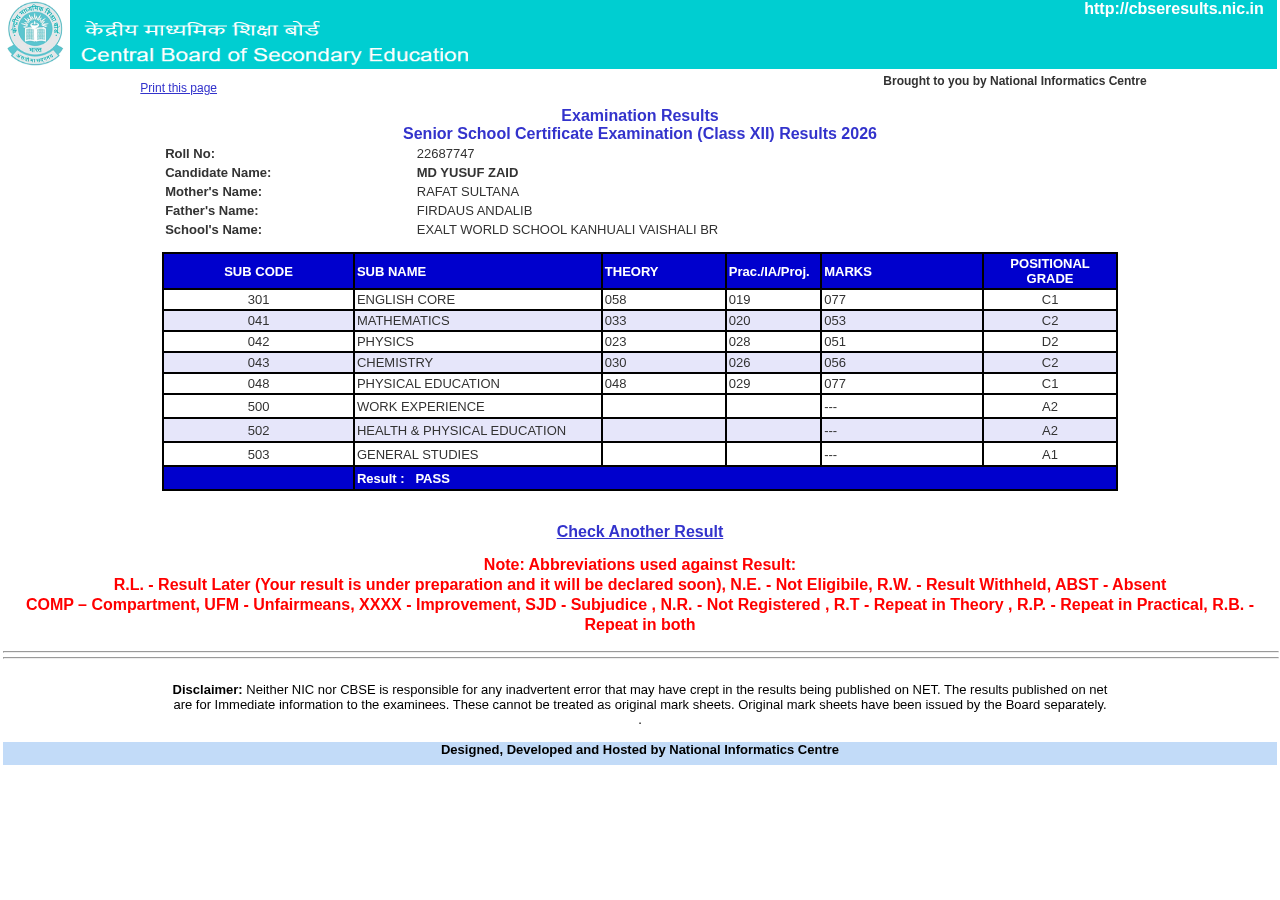



📥  PNG Download Links:



/content/cbse_results/result_22687719.png

/content/cbse_results/result_22687772.png

/content/cbse_results/result_22687735.png

/content/cbse_results/result_22687747.png

...

/content/cbse_results/result_22687735.pdf

/content/cbse_results/result_22687747.pdf



📦  Creating ZIP of all results…
  adding: result_22687719.png (deflated 6%)
  adding: result_22687735.png (deflated 6%)
  adding: result_22687747.png (deflated 6%)
  adding: result_22687772.png (deflated 6%)
  adding: result_22687719.pdf (deflated 5%)
  adding: result_22687735.pdf (deflated 5%)
  adding: result_22687747.pdf (deflated 5%)
  adding: result_22687772.pdf (deflated 5%)
✅  Zip ready:


/content/cbse_all_results.zip


📁  Sidebar path: /content/cbse_results
    Click the 📁 folder icon (left panel) → /content/cbse_results


In [1]:
# ============================================================
# CBSE Class 12 Result Extractor - Google Colab  [v2 - FIXED]
# ============================================================

# ── STEP 1: Install dependencies ──────────────────────────
!pip install playwright -q
!playwright install chromium
!playwright install-deps chromium
!apt-get install -y libgbm1 libasound2 -q

# ── STEP 2: Imports & Setup ────────────────────────────────
import asyncio, os, glob
from playwright.async_api import async_playwright
from IPython.display import display, Image, FileLink

# ── Credentials (all 4 students) ──────────────────────────
credentials_list = [
    {"roll_no": "22687719", "school_no": "65921", "admit_id": "IZ196543"},
    {"roll_no": "22687772", "school_no": "65921", "admit_id": "AN726543"},
    {"roll_no": "22687735", "school_no": "65921", "admit_id": "AR356543"},
    {"roll_no": "22687747", "school_no": "65921", "admit_id": "IA476543"},
]

TARGET_URL = "https://examinationservices.nic.in/cbseresults/class_xii_b_2026_a/ClassTwelfth_ii26.htm"
OUTPUT_DIR = "/content/cbse_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Core Function ──────────────────────────────────────────
async def fetch_result(page, cred: dict) -> dict:
    roll   = cred["roll_no"]
    school = cred["school_no"]
    admit  = cred["admit_id"]

    print(f"\n{'='*55}")
    print(f"📥  Roll: {roll} | School: {school} | Admit: {admit}")
    print(f"{'='*55}")

    await page.goto(TARGET_URL, wait_until="domcontentloaded", timeout=60_000)
    await page.wait_for_timeout(2000)

    # ── Positional filling using page.locator (not ElementHandle) ──
    # This avoids the triple_click issue entirely
    all_inputs = page.locator("input[type='text'], input:not([type])")
    count = await all_inputs.count()
    print(f"  🔍 Found {count} text input(s)")

    if count < 3:
        raise ValueError(f"Expected ≥3 inputs, found {count}")

    # Clear and fill each field positionally
    await all_inputs.nth(0).click()
    await all_inputs.nth(0).fill("")
    await all_inputs.nth(0).fill(roll)
    await page.wait_for_timeout(200)

    await all_inputs.nth(1).click()
    await all_inputs.nth(1).fill("")
    await all_inputs.nth(1).fill(school)
    await page.wait_for_timeout(200)

    await all_inputs.nth(2).click()
    await all_inputs.nth(2).fill("")
    await all_inputs.nth(2).fill(admit)
    await page.wait_for_timeout(200)

    print(f"  ✅ Fields filled: [{roll}] [{school}] [{admit}]")

    # ── Submit ────────────────────────────────────────────
    submit_selectors = [
        "input[type='submit']",
        "button[type='submit']",
        "input[type='button']",
        "button",
    ]
    submitted = False
    for sel in submit_selectors:
        btn = page.locator(sel).first
        if await btn.count() > 0:
            await btn.click()
            submitted = True
            print(f"  ✅ Submitted via: {sel}")
            break

    if not submitted:
        raise RuntimeError("Could not find a submit button.")

    await page.wait_for_timeout(4000)

    # ── Click Print link if present ───────────────────────
    print_selectors = [
        "a[href*='print' i]",
        "a[onclick*='print' i]",
        "input[value*='print' i]",
        "a:text-matches('print', 'i')",
        "button:text-matches('print', 'i')",
    ]
    for sel in print_selectors:
        try:
            el = page.locator(sel).first
            if await el.count() > 0:
                await el.click()
                await page.wait_for_timeout(1500)
                print(f"  🖨️  Print link clicked: {sel}")
                break
        except Exception:
            continue

    # ── Save PNG screenshot ───────────────────────────────
    png_path = os.path.join(OUTPUT_DIR, f"result_{roll}.png")
    await page.screenshot(path=png_path, full_page=True)
    print(f"  📸 PNG  → {png_path}")

    # ── Save PDF ──────────────────────────────────────────
    pdf_path = os.path.join(OUTPUT_DIR, f"result_{roll}.pdf")
    await page.pdf(
        path=pdf_path,
        format="A4",
        print_background=True,
        margin={"top": "10mm", "bottom": "10mm", "left": "10mm", "right": "10mm"}
    )
    print(f"  💾 PDF  → {pdf_path}")

    return {"roll_no": roll, "png": png_path, "pdf": pdf_path, "status": "success"}


# ── Main runner ────────────────────────────────────────────
async def main():
    results_log = []

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(
            headless=True,
            args=["--no-sandbox", "--disable-setuid-sandbox", "--disable-dev-shm-usage"]
        )
        context = await browser.new_context(viewport={"width": 1280, "height": 900})
        page    = await context.new_page()

        for cred in credentials_list:
            try:
                result = await fetch_result(page, cred)
                results_log.append(result)
            except Exception as e:
                print(f"\n  ❌ FAILED for Roll {cred['roll_no']}: {e}")
                results_log.append({"roll_no": cred["roll_no"], "status": "failed", "error": str(e)})

        await browser.close()
    return results_log


# ── RUN ────────────────────────────────────────────────────
results = await main()


# ============================================================
# STEP 3 — Show PNGs inline + sidebar links
# ============================================================
print("\n╔══════════════════════════════════════════╗")
print("║        📊  EXTRACTION SUMMARY            ║")
print("╚══════════════════════════════════════════╝")
for r in results:
    status = "✅ SUCCESS" if r["status"] == "success" else f"❌ FAILED: {r.get('error','?')}"
    print(f"  Roll {r['roll_no']} → {status}")

# ── Inline PNG previews ───────────────────────────────────
print("\n\n🖼️  Result Screenshots:\n")
for r in results:
    if r["status"] == "success":
        print(f"\n── Roll No: {r['roll_no']} ──────────────────────────")
        display(Image(r["png"], width=750))

# ── Per-file download links ───────────────────────────────
print("\n\n📥  PNG Download Links:\n")
for r in results:
    if r["status"] == "success":
        display(FileLink(r["png"],  result_html_prefix=f"🖼️  Roll {r['roll_no']} PNG: "))

print("\n📥  PDF Download Links:\n")
for r in results:
    if r["status"] == "success":
        display(FileLink(r["pdf"], result_html_prefix=f"📄  Roll {r['roll_no']} PDF: "))

# ── Bulk ZIP ──────────────────────────────────────────────
print("\n\n📦  Creating ZIP of all results…")
!zip -j /content/cbse_all_results.zip {OUTPUT_DIR}/*.png {OUTPUT_DIR}/*.pdf 2>/dev/null
print("✅  Zip ready:")
display(FileLink("/content/cbse_all_results.zip", result_html_prefix="⬇️  Download ALL (ZIP): "))

print(f"\n📁  Sidebar path: {OUTPUT_DIR}")
print("    Click the 📁 folder icon (left panel) → /content/cbse_results")
